# 04 — Сколько модель заработает? (бэктест и PnL)

С чем сравниваем:
- Buy & hold — просто держать монеты.
- Random — случайные покупки/продажи (монетка каждый день, среднее по 20 сидам):
  показывает, что без сигнала торговля лишь платит комиссию.
- Logistic regression — классический бейзлайн (`pca_svm_baseline`): та же задача
  классификации направления, но линейная модель на тех же признаках.
- GRU + Attention — наша модель (long-only и long-short).

Логика. Окно признаков заканчивается до целевого
дня (`window = X[i-seq_len:i]`, таргет `y[i]`),
поэтому позиция на день `i` принимается по информации, доступной накануне, и
зарабатывает реальную доходность дня `i`. Линейный бейзлайн использует последнюю
строку признаков перед целевым днём — та же причинность.

Учитываем комиссию за смену позиции (по умолчанию 10 б.п. за оборот).

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

import models, timeseries_cv
from models import (GRUWithAttention, WindowDataset, SoftDirectionalHuberLoss,
                    CURATED_FEATURES, get_device, save_checkpoint, load_checkpoint)
from pathlib import Path
from timeseries_cv import evaluate_holdout

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = get_device()

START_CAPITAL = 10_000.0   # стартовый капитал, $
FEE = 0.0010               # комиссия за оборот позиции (10 б.п.)
SEQ_LEN = 20
CKPT_PATH = Path('checkpoints/gru_attention_btc_eth.pt')
print('device:', DEVICE)

device: mps


## Данные и обучение модели

Тот же конвейер, что в `03`: train+val → пул, обучаемся, оцениваемся на test.
BTC+ETH, ядровой набор из 8 признаков.

In [2]:
HEADLINE = ['BTC-USD', 'ETH-USD']
def load(s): return pd.read_csv(f'data/{s}_features.csv', index_col=0, parse_dates=True)
def restrict(df, coins): return df[df['ticker'].isin(coins)].sort_index()

cv_df   = restrict(pd.concat([load('train'), load('val')]), HEADLINE)
test_df = restrict(load('test'), HEADLINE)

criterion = SoftDirectionalHuberLoss(delta=1.01, dir_weight=0.8, sharpness=10.0)
ARCH_CONFIG = dict(input_size=len(CURATED_FEATURES), hidden_size=32,
                   num_layers=3, linear_hidden=32, dropout=0.1)
def model_factory(seed=SEED):
    torch.manual_seed(seed)
    return GRUWithAttention(**ARCH_CONFIG).to(DEVICE)

# Импортируем чекпойнт из 03, если он есть; иначе обучаем и сохраняем.
if CKPT_PATH.exists():
    model, payload = load_checkpoint(CKPT_PATH, device=DEVICE)
    feature_cols = payload['feature_cols']; SEQ_LEN = payload['seq_len']
    print(f'loaded checkpoint {CKPT_PATH}  | metrics: {payload["metrics"]}')
else:
    feature_cols = list(CURATED_FEATURES)
    res = evaluate_holdout(
        train_df=cv_df, eval_df=test_df, feature_cols=feature_cols,
        model_factory=model_factory, dataset_cls=WindowDataset, lr=1e-3, device=DEVICE,
        seq_len=SEQ_LEN, batch_size=128, epochs=1000, patience=13, huber_delta=1.01,
        criterion=criterion, weight_decay=1e-1, warmup_epochs=10, ticker=HEADLINE,
    )
    model = res.model
    save_checkpoint(model, CKPT_PATH, config=ARCH_CONFIG, feature_cols=feature_cols,
                    seq_len=SEQ_LEN, arch='GRUWithAttention',
                    metrics={'holdout_dir_acc': float(res.eval_dir_acc)})
    print(f'trained & saved checkpoint  | GRU holdout dir-acc: {res.eval_dir_acc:.4f}')

loaded checkpoint checkpoints/gru_attention_btc_eth.pt  | metrics: {'holdout_dir_acc': 0.5580357313156128, 'holdout_loss': 0.3787465989589691, 'tickers': ['BTC-USD', 'ETH-USD']}


## Бейзлайн: логистическая регрессия

Та же причинная постановка: строка признаков дня `j` → знак таргета дня `j+1`.
Признаки уже z-нормализованы, поэтому отдельное масштабирование не требуется.

In [3]:
def make_class_dataset(df):
    Xs, ys = [], []
    for _, g in df.groupby('ticker'):
        g = g.sort_index()
        X = g[feature_cols].values.astype(np.float64)
        t = g['target'].values.astype(np.float64)
        m = np.isfinite(X).all(axis=1) & np.isfinite(t)
        X, t = X[m], t[m]
        Xs.append(X[:-1]); ys.append((t[1:] > 0).astype(int))   # строка j -> знак(target[j+1])
    return np.vstack(Xs), np.concatenate(ys)

X_tr, y_tr = make_class_dataset(cv_df)
clf = LogisticRegression(max_iter=1000, C=1.0).fit(X_tr, y_tr)
print(f'LogReg train accuracy: {clf.score(X_tr, y_tr):.4f}  | доля «вверх» в трейне: {y_tr.mean():.3f}')

LogReg train accuracy: 0.5431  | доля «вверх» в трейне: 0.497


## Причинное предсказание с привязкой к датам

Воспроизводим оконную логику `WindowDataset` (по тикерам, с маской), сохраняя для
каждого предсказания дату, реальную доходность, close и **последнюю строку
признаков** (вход для линейного бейзлайна). Реальная лог-доходность:
`real = target * target_scale + target_mu`.

In [4]:
@torch.no_grad()
def predict_aligned(model, df, feature_cols, seq_len=SEQ_LEN):
    model.eval()
    rows, prev_feats = [], []
    for ticker, g in df.groupby('ticker'):
        g = g.sort_index()
        X = g[feature_cols].values.astype(np.float32)
        y = g['target'].values.astype(np.float32)
        scale = g['target_scale'].values.astype(np.float64)
        mu = g['target_mu'].values.astype(np.float64)
        close = g['Close'].values.astype(np.float64)
        idx = g.index.values
        mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
        X, y, scale, mu, close, idx = X[mask], y[mask], scale[mask], mu[mask], close[mask], idx[mask]
        for i in range(seq_len, len(X)):
            w = torch.from_numpy(X[i-seq_len:i]).unsqueeze(0).to(DEVICE)
            pred, _ = model(w)
            rows.append({'date': idx[i], 'ticker': ticker, 'pred': float(pred.item()),
                         'real_log_ret': float(y[i]) * float(scale[i]) + float(mu[i]),
                         'close': float(close[i])})
            prev_feats.append(X[i-1])           # последняя строка перед таргетом
    res = pd.DataFrame(rows)
    res['date'] = pd.to_datetime(res['date'])
    feats = np.asarray(prev_feats, dtype=np.float64)
    # причинный сигнал линейного бейзлайна (знак = предсказанный класс)
    res['pred_logreg'] = clf.decision_function(feats)
    return res                                  # строки уже в порядке (ticker, date)

signals = predict_aligned(model, test_df, feature_cols)
print(signals.shape)
print('hit rate GRU   :', (np.sign(signals.pred)        == np.sign(signals.real_log_ret)).mean().round(4))
print('hit rate LogReg:', (np.sign(signals.pred_logreg) == np.sign(signals.real_log_ret)).mean().round(4))
signals.head()

(448, 6)
hit rate GRU   : 0.5089
hit rate LogReg: 0.4955


,date,ticker,pred,real_log_ret,close,pred_logreg
0,2025-07-30,BTC-USD,-0.309605,-0.017749,117831.187500,-0.152985
1,2025-07-31,BTC-USD,-0.294349,-0.021287,115758.203125,-0.157632
2,2025-08-01,BTC-USD,-0.285686,-0.007024,113320.085938,-0.064747
3,2025-08-02,BTC-USD,-0.286518,0.014914,112526.914062,0.002412
4,2025-08-03,BTC-USD,-0.283695,0.007451,114217.671875,-0.075169


## Движок бэктеста

Позиция на день `i` берётся из выбранного сигнала и зарабатывает простую доходность
дня (`expm1` от лог-доходности). Комиссия — при изменении позиции относительно
предыдущего дня. Эквити — кумулятивное произведение `(1 + дневная)`. Движок
параметризован колонкой сигнала, так что одинаков для GRU, LogReg и Random.

In [5]:
def run_strategy(sig, pred_col='pred', mode='long_short', fee=FEE):
    d = sig.sort_values('date').copy()
    simple = np.expm1(d['real_log_ret'].values)
    if mode == 'long_only':
        pos = (d[pred_col].values > 0).astype(float)      # 1 / 0
    else:
        pos = np.sign(d[pred_col].values)                 # +1 / -1
    turnover = np.abs(np.diff(np.concatenate([[0.0], pos])))
    strat = pos * simple - fee * turnover
    d['position'] = pos; d['simple_ret'] = simple; d['strat_ret'] = strat
    d['equity'] = (1 + strat).cumprod(); d['bh_equity'] = (1 + simple).cumprod()
    return d

def combine(sig, pred_col='pred', mode='long_short', fee=FEE):
    per = {tk: run_strategy(g, pred_col, mode, fee) for tk, g in sig.groupby('ticker')}
    daily = (pd.concat([d.set_index('date')[['strat_ret', 'simple_ret']] for d in per.values()])
               .groupby('date').mean())
    daily['equity'] = (1 + daily['strat_ret']).cumprod()
    daily['bh_equity'] = (1 + daily['simple_ret']).cumprod()
    return daily, per

def metrics(daily, ret_col='strat_ret', eq_col='equity', periods_per_year=365):
    r = daily[ret_col].values; eq = daily[eq_col].values; n = len(r)
    sharpe = (r.mean() / r.std() * np.sqrt(periods_per_year)) if r.std() > 0 else np.nan
    peak = np.maximum.accumulate(eq); mdd = ((eq - peak) / peak).min()
    return {'total_return': eq[-1] - 1, 'CAGR': eq[-1] ** (periods_per_year / n) - 1,
            'ann_vol': r.std() * np.sqrt(periods_per_year), 'Sharpe': sharpe,
            'max_drawdown': mdd, 'win_rate': (r > 0).mean(), 'days': n}

## Сравнение стратегий: GRU vs LogReg vs Random vs Buy & Hold

In [6]:
rows = []

def add(name, daily, ret_col='strat_ret', eq_col='equity'):
    m = metrics(daily, ret_col, eq_col); m['strategy'] = name
    m['final_$'] = START_CAPITAL * daily[eq_col].iloc[-1]; rows.append(m)

for name, col, mode in [('GRU (long-only)', 'pred', 'long_only'),
                        ('GRU (long-short)', 'pred', 'long_short'),
                        ('LogReg (long-short)', 'pred_logreg', 'long_short')]:
    daily, _ = combine(signals, pred_col=col, mode=mode, fee=FEE); add(name, daily)

# Random: среднее по 20 сидам (одна монетка слишком шумная)
rand = []
for s in range(20):
    rng = np.random.default_rng(s)
    signals['pred_random'] = rng.choice([-1.0, 1.0], len(signals))
    daily, _ = combine(signals, pred_col='pred_random', mode='long_short', fee=FEE)
    rand.append(metrics(daily) | {'final_$': START_CAPITAL * daily['equity'].iloc[-1]})
rand_df = pd.DataFrame(rand)
rows.append({'strategy': 'Random (avg 20 сидов)', 'final_$': rand_df['final_$'].mean(),
             'total_return': rand_df['total_return'].mean(), 'CAGR': rand_df['CAGR'].mean(),
             'ann_vol': rand_df['ann_vol'].mean(), 'Sharpe': rand_df['Sharpe'].mean(),
             'max_drawdown': rand_df['max_drawdown'].mean(), 'win_rate': rand_df['win_rate'].mean(),
             'days': int(rand_df['days'].mean())})

daily_bh, _ = combine(signals, pred_col='pred', mode='long_only', fee=0.0)
add('Buy & hold', daily_bh, ret_col='simple_ret', eq_col='bh_equity')

summary = pd.DataFrame(rows).set_index('strategy')[
    ['final_$', 'total_return', 'CAGR', 'ann_vol', 'Sharpe', 'max_drawdown', 'win_rate', 'days']]
print(f'Старт ${START_CAPITAL:,.0f} | комиссия {FEE*1e4:.0f} б.п./оборот | BTC+ETH | период = holdout (test)')
summary.round({'final_$': 0, 'total_return': 4, 'CAGR': 4, 'ann_vol': 4, 'Sharpe': 2, 'max_drawdown': 4, 'win_rate': 4})

Старт $10,000 | комиссия 10 б.п./оборот | BTC+ETH | период = holdout (test)


,final_$,total_return,CAGR,ann_vol,Sharpe,max_drawdown,win_rate,days
strategy,,,,,,,,
GRU (long-only),8266.0,-0.1734,-0.2667,0.3769,-0.63,-0.3106,0.1875,224
GRU (long-short),10619.0,0.0619,0.1029,0.5582,0.46,-0.3086,0.5134,224
LogReg (long-short),10249.0,0.0249,0.0409,0.5702,0.36,-0.4067,0.4777,224
Random (avg 20 сидов),7645.0,-0.2355,-0.3124,0.4297,-1.04,-0.4217,0.4612,224
Buy & hold,5736.0,-0.4264,-0.5958,0.5850,-1.25,-0.5557,0.4688,224


## Кривые капитала (все стратегии)

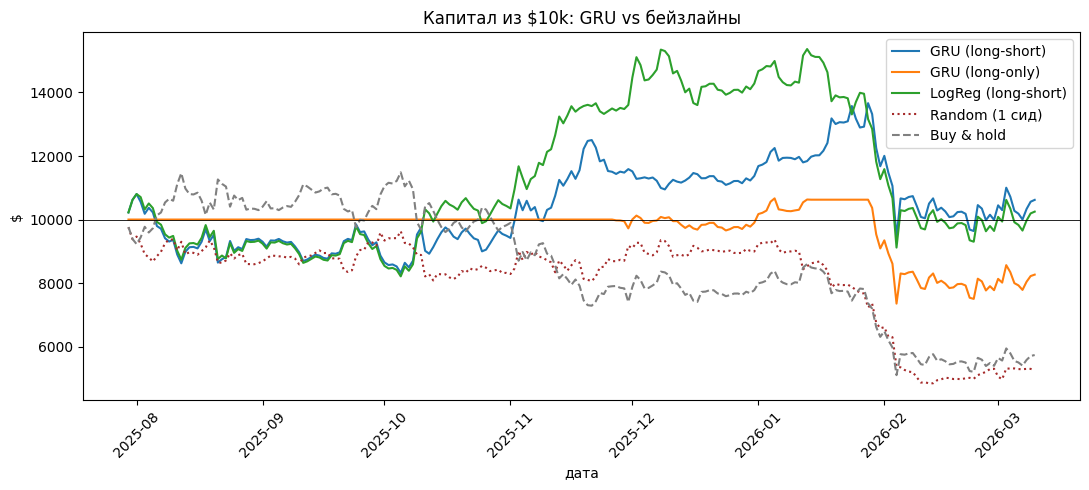

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, col, mode, style in [('GRU (long-short)', 'pred', 'long_short', '-'),
                               ('GRU (long-only)', 'pred', 'long_only', '-'),
                               ('LogReg (long-short)', 'pred_logreg', 'long_short', '-')]:
    daily, _ = combine(signals, pred_col=col, mode=mode, fee=FEE)
    ax.plot(daily.index, START_CAPITAL * daily['equity'], style, label=name)

rng = np.random.default_rng(0)
signals['pred_random'] = rng.choice([-1.0, 1.0], len(signals))
daily_r, _ = combine(signals, pred_col='pred_random', mode='long_short', fee=FEE)
ax.plot(daily_r.index, START_CAPITAL * daily_r['equity'], ':', c='brown', label='Random (1 сид)')
ax.plot(daily_bh.index, START_CAPITAL * daily_bh['bh_equity'], '--', c='gray', label='Buy & hold')

ax.axhline(START_CAPITAL, c='k', lw=0.6)
ax.set_title('Капитал из $10k: GRU vs бейзлайны'); ax.set_xlabel('дата'); ax.set_ylabel('$')
ax.tick_params(axis='x', rotation=45); ax.legend(); plt.tight_layout(); plt.show()

## Чувствительность к комиссии

Слабый край держится только при низких издержках. Сравниваем, как комиссия съедает
итоговую доходность у GRU и линейного бейзлайна.

In [8]:
fees = [0.0, 0.0005, 0.0010, 0.0025, 0.0050]
rows = []
for f in fees:
    for name, col in [('GRU (long-short)', 'pred'), ('LogReg (long-short)', 'pred_logreg')]:
        daily, _ = combine(signals, pred_col=col, mode='long_short', fee=f)
        rows.append({'fee_bps': f*1e4, 'strategy': name, 'total_return': metrics(daily)['total_return']})
pd.DataFrame(rows).pivot(index='fee_bps', columns='strategy', values='total_return').round(4)

strategy,GRU (long-short),LogReg (long-short)
fee_bps,,
0.0,0.0694,0.0570
5.0,0.0657,0.0409
10.0,0.0619,0.0249
25.0,0.0508,-0.0215
50.0,0.0325,-0.0944


## Выводы
Как видно наши модели отиграли почти в 0. Радном и buy & hold ушли в минус. Однако моя модель не лучше регресии, что обидно;